##### Caso 1 clase del 31

##### Importacion de las librerias necesarias para el analisis de la data set

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

#### Se utiliza la palabra DF para definir la funcion que leera toda la data set en la nomenclatura

In [7]:
df = pd.read_csv('chocolate/flavors_of_cacao.csv')

#### Utilizamos la funcion .head para saber todos los cabezales de la base de datos

In [8]:
df.head()

,Company \n(Maker-if known),Specific Bean Origin\nor Bar Name,REF,Review\nDate,Cocoa\nPercent,Company\nLocation,Rating,Bean\nType,Broad Bean\nOrigin
0,A. Morin,Agua Grande,1876,2016,63%,France,3.75,,Sao Tome
1,A. Morin,Kpime,1676,2015,70%,France,2.75,,Togo
2,A. Morin,Atsane,1676,2015,70%,France,3.00,,Togo
3,A. Morin,Akata,1680,2015,70%,France,3.50,,Togo
4,A. Morin,Quilla,1704,2015,70%,France,3.50,,Peru


##### Sape nos da el registro total de registros y la cantidad de columnas que tenemos

In [9]:
df.shape

(1795, 9)

##### El .info nos da todos los tipos de datos de nuestros atributos

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1795 entries, 0 to 1794
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Company 
(Maker-if known)         1795 non-null   str    
 1   Specific Bean Origin
or Bar Name  1795 non-null   str    
 2   REF                               1795 non-null   int64  
 3   Review
Date                       1795 non-null   int64  
 4   Cocoa
Percent                     1795 non-null   str    
 5   Company
Location                  1795 non-null   str    
 6   Rating                            1795 non-null   float64
 7   Bean
Type                         1794 non-null   str    
 8   Broad Bean
Origin                 1794 non-null   str    
dtypes: float64(1), int64(2), str(6)
memory usage: 126.3 KB


#### .describe nos da la descripcion total de todos los campos necesarios que tenemos 

In [11]:
df.describe()

,REF,Review\nDate,Rating
count,1795.000000,1795.000000,1795.000000
mean,1035.904735,2012.325348,3.185933
std,552.886365,2.927210,0.478062
min,5.000000,2006.000000,1.000000
25%,576.000000,2010.000000,2.875000
50%,1069.000000,2013.000000,3.250000
75%,1502.000000,2015.000000,3.500000
max,1952.000000,2017.000000,5.000000


#### .isnull nos da todos los registros nulos o vacios de nuestros atributos

In [12]:
df.isnull().sum()

Company \n(Maker-if known)           0
Specific Bean Origin\nor Bar Name    0
REF                                  0
Review\nDate                         0
Cocoa\nPercent                       0
Company\nLocation                    0
Rating                               0
Bean\nType                           1
Broad Bean\nOrigin                   1
dtype: int64

##### importamos la libreria missingno para la graficacion de los valores nulos y la relacion

In [13]:
import missingno as msno

<Axes: >

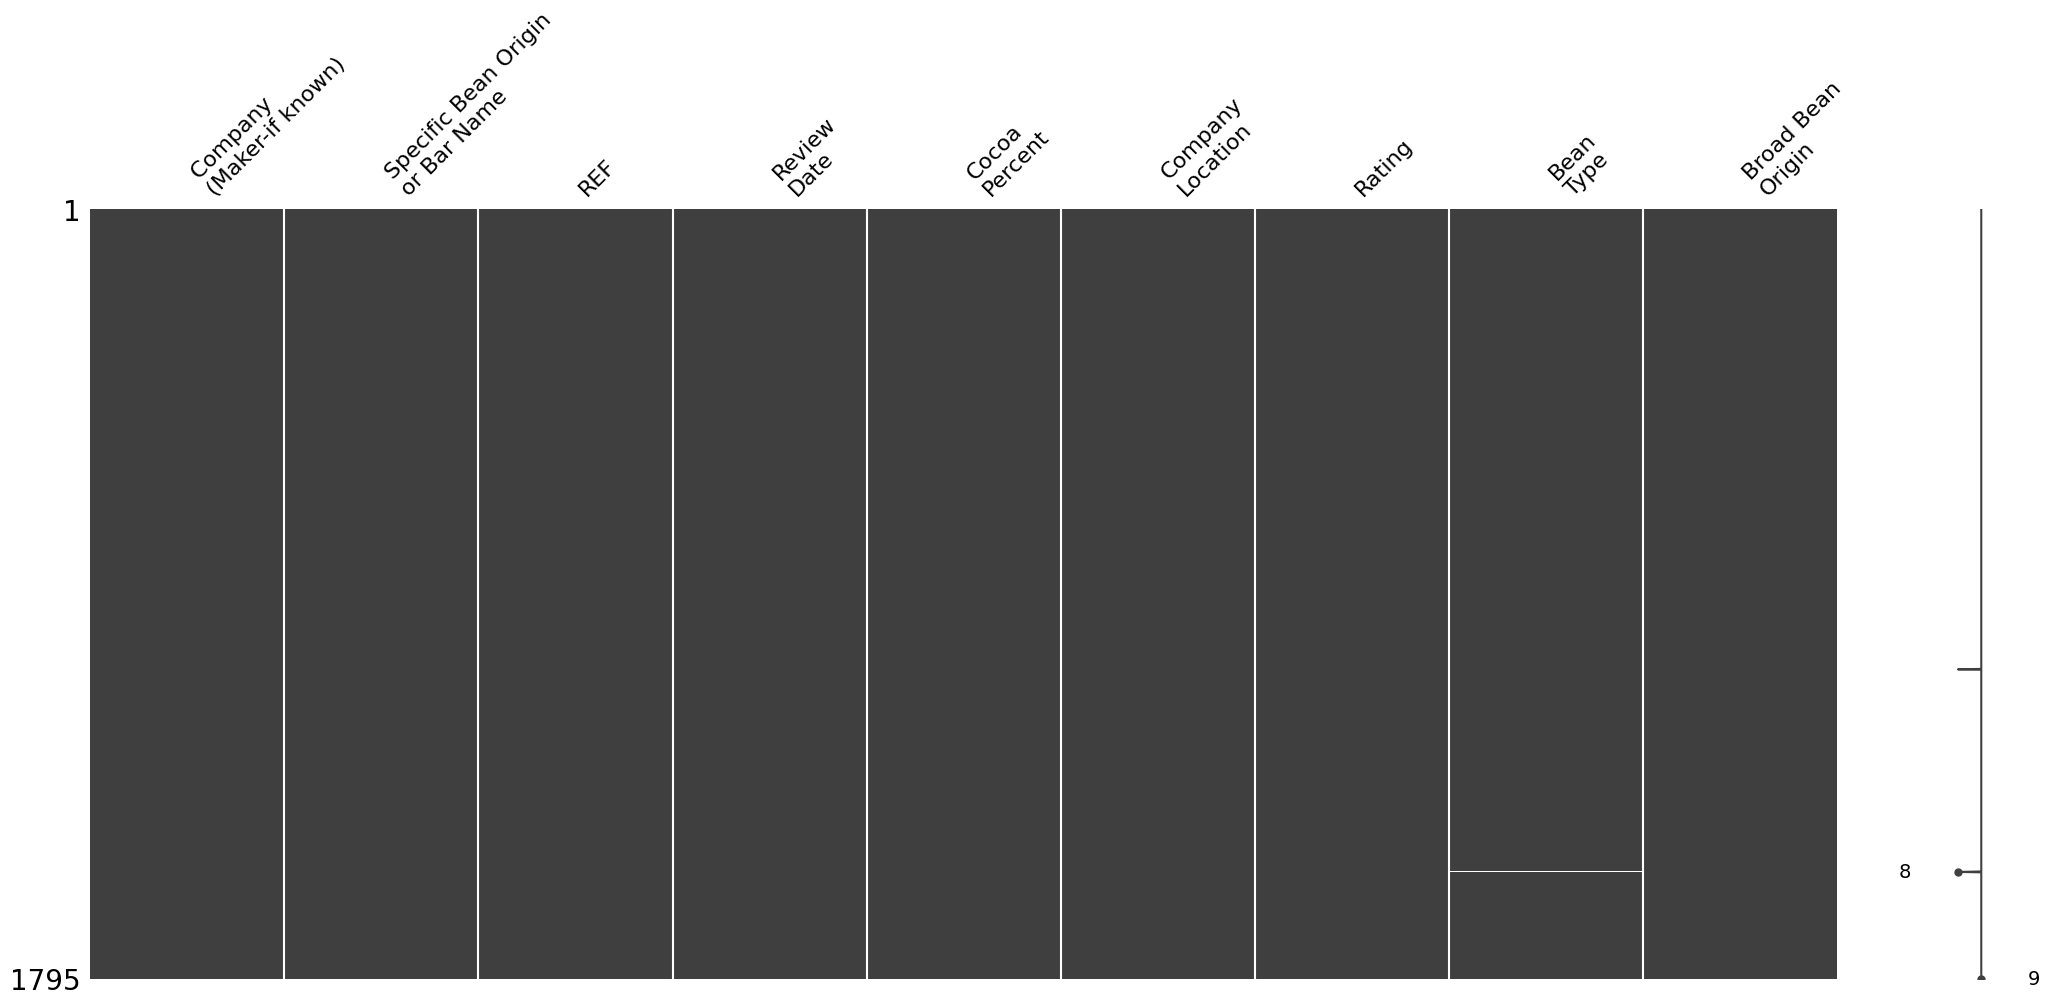

In [14]:
msno.matrix(df)

#### Tipo de grano

In [15]:
df["Bean\nType"].fillna(
    df["Bean\nType"].mode()[0],
    inplace=True
)

C:\Users\Sarab\AppData\Local\Temp\ipykernel_508\891280951.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Bean\nType"].fillna(


0                
1                
2                
3                
4                
          ...    
1790             
1791    Forastero
1792    Forastero
1793             
1794             
Name: Bean\nType, Length: 1795, dtype: str

#### Origen amplio del grano

In [16]:
df["Broad Bean\nOrigin"].fillna(
    df["Broad Bean\nOrigin"].mode()[0],
    inplace=True
)

C:\Users\Sarab\AppData\Local\Temp\ipykernel_508\1217514069.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Broad Bean\nOrigin"].fillna(


0       Sao Tome
1           Togo
2           Togo
3           Togo
4           Peru
          ...   
1790        Peru
1791       Congo
1792       India
1793       India
1794      Brazil
Name: Broad Bean\nOrigin, Length: 1795, dtype: str

#### Una vez teniendo los atributos 

In [17]:
df.isnull().sum()

Company \n(Maker-if known)           0
Specific Bean Origin\nor Bar Name    0
REF                                  0
Review\nDate                         0
Cocoa\nPercent                       0
Company\nLocation                    0
Rating                               0
Bean\nType                           1
Broad Bean\nOrigin                   1
dtype: int64

In [18]:
df[df["Company\nLocation"]== "Peru"]

,Company \n(Maker-if known),Specific Bean Origin\nor Bar Name,REF,Review\nDate,Cocoa\nPercent,Company\nLocation,Rating,Bean\nType,Broad Bean\nOrigin
67,Amazona,"LamasdelChanka, San Martin, Oro Verde coop",1145,2013,72%,Peru,3.25,,Peru
68,Amazona,"Bellavista Gran Pajeten, San Martin",1145,2013,73%,Peru,3.50,Trinitario,Peru
149,Bakau,"Bambamarca, 2015",1454,2015,70%,Peru,2.75,,Peru
150,Bakau,"Huallabamba, 2015",1454,2015,70%,Peru,3.50,,Peru
320,Cacaosuyo (Theobroma Inversiones),Piura,1173,2013,70%,Peru,3.25,,Peru
940,La Oroquidea,Peruvian Amazon,721,2011,72%,Peru,2.50,,Peru
988,Machu Picchu Trading Co.,Peru,721,2011,70%,Peru,1.50,,Peru
989,Machu Picchu Trading Co.,Peru,552,2010,55%,Peru,2.25,,Peru
1045,Marana,Piura,1872,2016,70%,Peru,3.00,,Peru
1046,Marana,Cusco,1884,2016,70%,Peru,2.75,,Peru


In [22]:
df[df["Review\nDate"]== 2011]

,Company \n(Maker-if known),Specific Bean Origin\nor Bar Name,REF,Review\nDate,Cocoa\nPercent,Company\nLocation,Rating,Bean\nType,Broad Bean\nOrigin
25,Adi,Vanua Levu,705,2011,60%,Fiji,2.75,Trinitario,Fiji
26,Adi,"Vanua Levu, Toto-A",705,2011,80%,Fiji,3.25,Trinitario,Fiji
27,Adi,Vanua Levu,705,2011,88%,Fiji,3.50,Trinitario,Fiji
28,Adi,"Vanua Levu, Ami-Ami-CA",705,2011,72%,Fiji,3.50,Trinitario,Fiji
32,Akesson's (Pralus),"Bali (west), Sukrama Family, Melaya area",636,2011,75%,Switzerland,3.75,Trinitario,Indonesia
...,...,...,...,...,...,...,...,...,...
1777,Zokoko,"Tranquilidad, Baures",701,2011,72%,Australia,3.75,,Bolivia
1790,Zotter,Peru,647,2011,70%,Austria,3.75,,Peru
1791,Zotter,Congo,749,2011,65%,Austria,3.00,Forastero,Congo
1792,Zotter,Kerala State,749,2011,65%,Austria,3.50,Forastero,India


In [24]:
muestra = df.sample(
    n=50,
    random_state=42
)

muestra

,Company \n(Maker-if known),Specific Bean Origin\nor Bar Name,REF,Review\nDate,Cocoa\nPercent,Company\nLocation,Rating,Bean\nType,Broad Bean\nOrigin
1234,Original Beans (Felchlin),"Piura, Apotequil, ""Porcelana"" 72hr c.",341,2009,75%,Switzerland,3.00,Criollo,Peru
220,Blue Bandana,Madagascar,911,2012,70%,U.S.A.,3.75,Trinitario,Madagascar
1516,Soma,"La Tronca, Matagalpa",1227,2014,70%,Canada,3.50,,Nicaragua
438,Cloudforest,"Camino Verde P., Balao, Guayas, 2014",1486,2015,73%,U.S.A.,3.50,,Ecuador
1268,Parliament,Alto Beni,1251,2014,70%,U.S.A.,3.00,,Bolivia
832,Hotel Chocolat (Coppeneur),"Somia Plantation, Akesson, 2012",1065,2013,72%,U.K.,3.00,Trinitario,Madagascar
692,Fresco,"Ghana, #211, MR, MC",636,2011,74%,U.S.A.,2.75,Forastero,Ghana
1307,Potomac,"Oko Caribe, Duarte Province, 2016 H.",1820,2016,70%,U.S.A.,3.75,,Domincan Republic
1100,Menakao (aka Cinagra),Madagascar,837,2012,80%,Madagascar,2.50,Trinitario,Madagascar
1526,Soma,Chef's Blend,1077,2013,70%,Canada,3.25,,


In [25]:
muestra.describe()

,REF,Review\nDate,Rating
count,50.000000,50.00000,50.000000
mean,1016.820000,2012.32000,3.165000
std,509.596707,2.69118,0.475443
min,15.000000,2006.00000,2.000000
25%,658.500000,2011.00000,2.750000
50%,1014.500000,2012.50000,3.250000
75%,1477.000000,2015.00000,3.500000
max,1864.000000,2016.00000,4.000000


In [26]:
df.describe()

,REF,Review\nDate,Rating
count,1795.000000,1795.000000,1795.000000
mean,1035.904735,2012.325348,3.185933
std,552.886365,2.927210,0.478062
min,5.000000,2006.000000,1.000000
25%,576.000000,2010.000000,2.875000
50%,1069.000000,2013.000000,3.250000
75%,1502.000000,2015.000000,3.500000
max,1952.000000,2017.000000,5.000000


In [29]:
df["Company\nLocation"] = df["Company\nLocation"].map({
    "Peru": 0,
    "Colombia": 1,
})

In [30]:
df.head()

,Company \n(Maker-if known),Specific Bean Origin\nor Bar Name,REF,Review\nDate,Cocoa\nPercent,Company\nLocation,Rating,Bean\nType,Broad Bean\nOrigin
0,A. Morin,Agua Grande,1876,NaN,63%,NaN,3.75,,Sao Tome
1,A. Morin,Kpime,1676,NaN,70%,NaN,2.75,,Togo
2,A. Morin,Atsane,1676,NaN,70%,NaN,3.00,,Togo
3,A. Morin,Akata,1680,NaN,70%,NaN,3.50,,Togo
4,A. Morin,Quilla,1704,NaN,70%,NaN,3.50,,Peru
